# Data Visualization & Explanatory Analysis
Notebook ini bertujuan untuk menjawab 4 Pertanyaan Bisnis utama terkait pergerakan harga komoditas pangan.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('data/cleaned/pihps_featured.csv', parse_dates=['tanggal'])
df['tahun'] = df['tanggal'].dt.year
print(f"Data dimuat: {df.shape[0]} baris.")
df.head(3)


Data dimuat: 23709 baris.


,Komoditas,tanggal,harga,sumber,is_outlier,is_holiday,is_ramadan,days_to_lebaran,suhu_rata2,curah_hujan,kecepatan_angin,tahun
0,Bawang Merah Ukuran Sedang,2022-01-03,30200.00,PIHPS,False,0,0,-119,27.40,0.50,10.60,2022
1,Bawang Merah Ukuran Sedang,2022-01-04,30150.00,PIHPS,False,0,0,-118,27.40,0.00,10.20,2022
2,Bawang Merah Ukuran Sedang,2022-01-05,30300.00,PIHPS,False,0,0,-117,26.40,13.00,8.90,2022


## Pertanyaan 1: Pertumbuhan YoY Beras dan Daging Sapi
**Bagaimana tingkat pertumbuhan harga secara Year-on-Year (YoY) untuk kelompok komoditas beras dan daging sapi selama periode Januari 2022 hingga April 2026?**


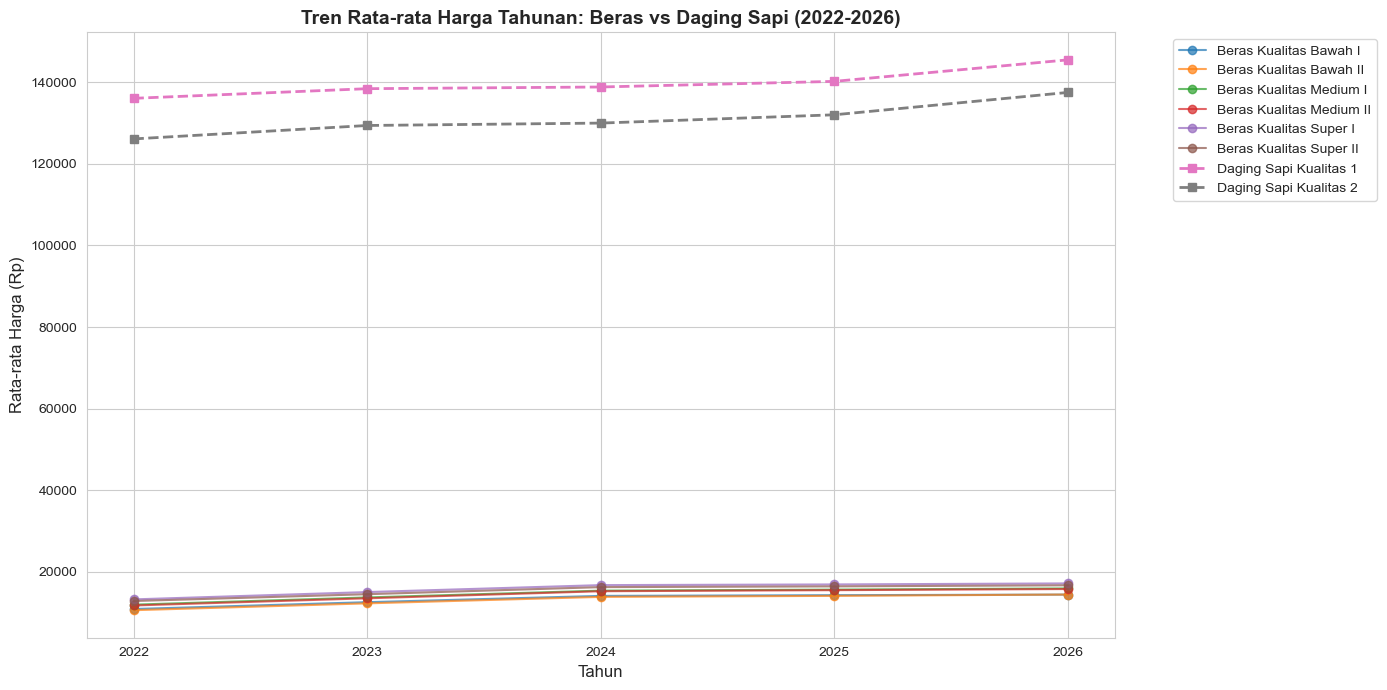

Tingkat Pertumbuhan Harga YoY (%):


Komoditas,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,Beras Kualitas Super II,Daging Sapi Kualitas 1,Daging Sapi Kualitas 2
tahun,,,,,,,,
2022,-,-,-,-,-,-,-,-
2023,15.38,15.78,14.76,14.90,13.49,12.95,1.74,2.61
2024,12.24,12.88,12.09,12.82,11.31,11.92,0.30,0.45
2025,1.24,1.81,1.65,1.71,1.01,1.13,0.99,1.56
2026,1.00,2.31,1.88,1.80,1.48,1.59,3.76,4.15


In [7]:
# Filter komoditas Beras dan Daging Sapi
beras_daging = df[df['Komoditas'].str.contains('Beras|Daging Sapi', case=False, na=False)]

# Hitung rata-rata tahunan per komoditas
yoy_data = beras_daging.groupby(['tahun', 'Komoditas'])['harga'].mean().unstack('Komoditas')

# Hitung persen perubahan YoY
yoy_pct = yoy_data.pct_change(axis=0) * 100

# Visualisasi Tren Harga Rata-rata
plt.figure(figsize=(14, 7))
for col in yoy_data.columns:
    if 'Beras' in str(col):
       plt.plot(yoy_data.index, yoy_data[col], marker='o', linestyle='-', label=col, alpha=0.7)
    else:
        plt.plot(yoy_data.index, yoy_data[col], marker='s', linestyle='--', label=col, linewidth=2)

plt.title('Tren Rata-rata Harga Tahunan: Beras vs Daging Sapi (2022-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rata-rata Harga (Rp)', fontsize=12)
plt.xticks([2022, 2023, 2024, 2025, 2026])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Tampilkan tabel pertumbuhan YoY
print("Tingkat Pertumbuhan Harga YoY (%):")
display(yoy_pct.round(2).fillna('-'))


**Insight (Q1):** Berdasarkan grafik dan perhitungan YoY di atas, kelompok beras menunjukkan tren kenaikan harga yang konsisten setiap tahunnya, khususnya melonjak pada tahun 2023 dan 2024. Sementara itu, Daging Sapi menunjukkan tingkat kenaikan yang jauh lebih stabil dan tidak berfluktuasi tajam (kenaikan tipis dan perlahan).


## Pertanyaan 2: Komoditas Paling Volatil dan Paling Stabil (CV)
**Berdasarkan perhitungan Coefficient of Variation (CV), apa saja 3 komoditas dengan tingkat fluktuasi harga tertinggi dan 1 komoditas dengan tingkat stabilitas tertinggi dari Januari 2022 hingga April 2026?**


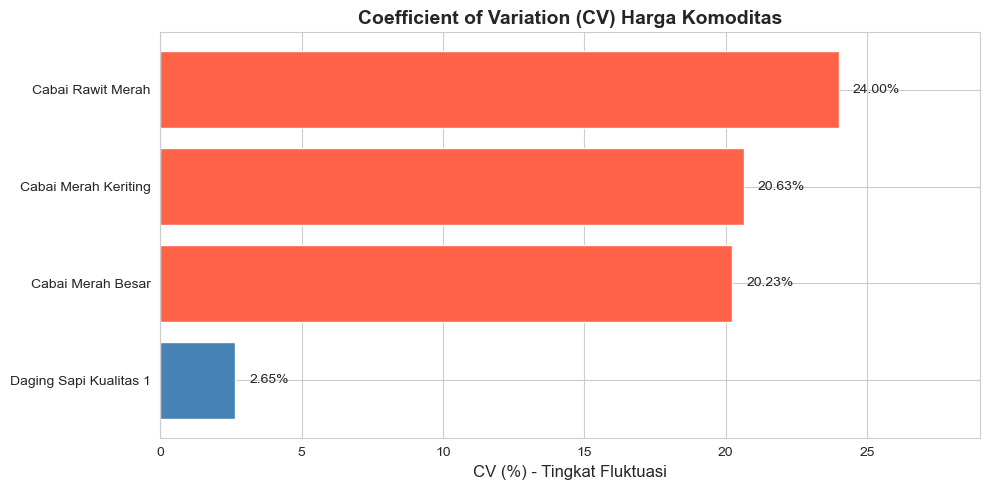

Top 3 Komoditas Paling Volatil:


,mean,std,cv
Komoditas,,,
Cabai Rawit Merah,62296.99,14952.31,24.00
Cabai Merah Keriting,51079.61,10540.18,20.63
Cabai Merah Besar,50788.06,10273.84,20.23



Komoditas Paling Stabil:


,mean,std,cv
Komoditas,,,
Daging Sapi Kualitas 1,138900.82,3676.44,2.65


In [8]:
# Menghitung CV = (Standard Deviation / Mean) * 100
stats = df.groupby('Komoditas')['harga'].agg(['mean', 'std'])
stats['cv'] = (stats['std'] / stats['mean']) * 100

# Urutkan berdasarkan CV
stats_sorted = stats.sort_values(by='cv', ascending=False)

top_3_volatil = stats_sorted.head(3)
top_1_stabil = stats_sorted.tail(1)

cv_gabungan = pd.concat([top_3_volatil, top_1_stabil])

# Visualisasi
plt.figure(figsize=(10, 5))
colors = ['tomato' if i < 3 else 'steelblue' for i in range(len(cv_gabungan))]
bars = plt.barh(cv_gabungan.index[::-1], cv_gabungan['cv'][::-1], color=colors[::-1])

plt.title('Coefficient of Variation (CV) Harga Komoditas', fontsize=14, fontweight='bold')
plt.xlabel('CV (%) - Tingkat Fluktuasi', fontsize=12)
plt.xlim(0, max(cv_gabungan['cv']) + 5)

for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f}%", va='center')

plt.tight_layout()
plt.show()

print("Top 3 Komoditas Paling Volatil:")
display(top_3_volatil)
print("\nKomoditas Paling Stabil:")
display(top_1_stabil)


**Insight (Q2):** Tiga komoditas dengan tingkat volatilitas (fluktuasi) tertinggi adalah kelompok Cabai (terutama Cabai Rawit Merah dengan CV tertinggi). Ini menandakan pergerakan harga cabai sangat ekstrem dan tidak menentu. Sebaliknya, Daging Sapi Kualitas 1 (dan 2) adalah komoditas dengan harga paling stabil dengan CV di bawah 3%.


## Pertanyaan 3: Efek Ramadan terhadap Komoditas Tertentu
**Berapa persentase lonjakan rata-rata harga pada komoditas Cabai Rawit Merah, Minyak Goreng Curah, dan Daging Ayam Ras Segar selama periode bulan Ramadan (is_ramadan) dibandingkan bulan reguler?**


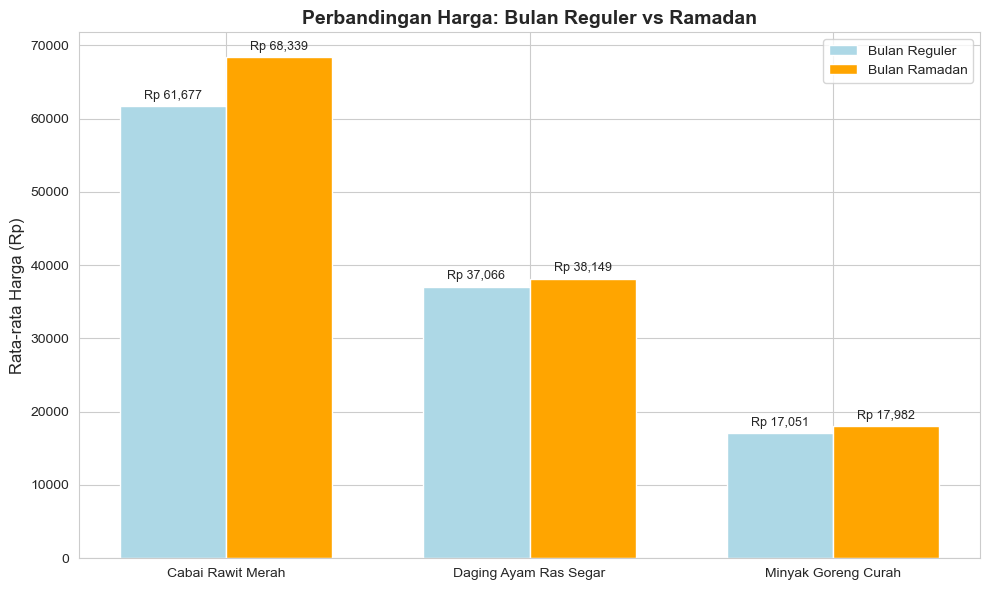

Rata-rata Harga dan Persentase Lonjakan:


,Bulan_Reguler,Bulan_Ramadan,Persentase_Lonjakan
Komoditas,,,
Cabai Rawit Merah,61677.44,68339.05,10.80
Daging Ayam Ras Segar,37066.14,38149.05,2.92
Minyak Goreng Curah,17051.98,17982.86,5.46


In [9]:
target_komoditas = ['Cabai Rawit Merah', 'Minyak Goreng Curah', 'Daging Ayam Ras Segar']
df_target = df[df['Komoditas'].isin(target_komoditas)]

# Hitung rata-rata harga saat Ramadan vs Non-Ramadan
ramadan_avg = df_target.groupby(['Komoditas', 'is_ramadan'])['harga'].mean().unstack('is_ramadan')
ramadan_avg.columns = ['Bulan_Reguler', 'Bulan_Ramadan']

# Hitung Persentase Lonjakan
ramadan_avg['Persentase_Lonjakan'] = ((ramadan_avg['Bulan_Ramadan'] - ramadan_avg['Bulan_Reguler']) / ramadan_avg['Bulan_Reguler']) * 100

# Visualisasi Grouped Bar Chart
x = np.arange(len(ramadan_avg.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, ramadan_avg['Bulan_Reguler'], width, label='Bulan Reguler', color='lightblue')
rects2 = ax.bar(x + width/2, ramadan_avg['Bulan_Ramadan'], width, label='Bulan Ramadan', color='orange')

ax.set_ylabel('Rata-rata Harga (Rp)', fontsize=12)
ax.set_title('Perbandingan Harga: Bulan Reguler vs Ramadan', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ramadan_avg.index)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'Rp {int(height):,}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

print("Rata-rata Harga dan Persentase Lonjakan:")
display(ramadan_avg.round(2))


**Insight (Q3):** Terbukti secara empiris bahwa sentimen bulan Ramadan memicu kenaikan harga. Cabai Rawit Merah mengalami lonjakan tertinggi secara persentase selama Ramadan, diikuti oleh Minyak Goreng Curah dan Daging Ayam Ras Segar. Hal ini membuktikan bahwa momentum hari raya secara konsisten mengeksploitasi pasokan dan mendongkrak harga pasar.


## Pertanyaan 4: Korelasi Curah Hujan vs Cabai & Bawang Merah
**Sejauh mana tingkat korelasi antara curah hujan harian (mm) dengan persentase perubahan harga harian pada kelompok Cabai dan Bawang Merah?**


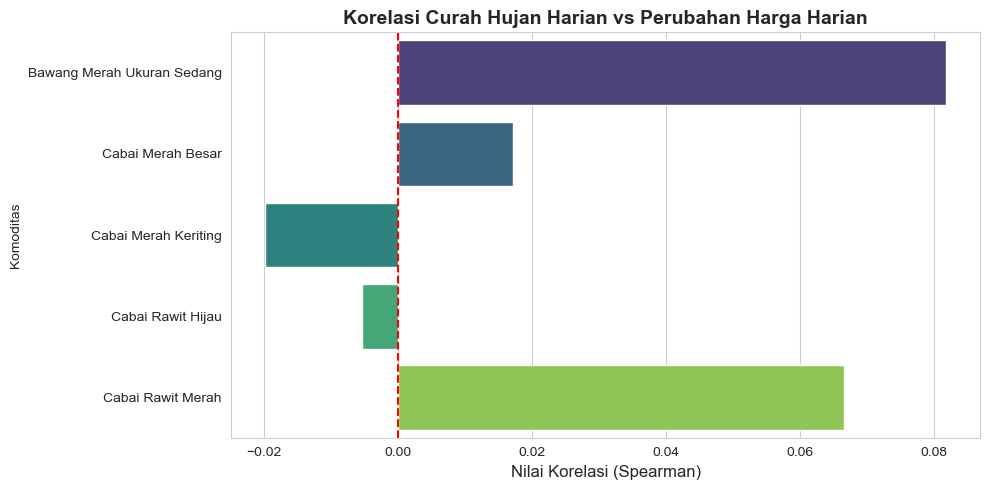

Tabel Korelasi (Curah Hujan vs Persentase Perubahan Harga Harian):


,Komoditas,Korelasi (Spearman)
0,Bawang Merah Ukuran Sedang,0.08
1,Cabai Merah Besar,0.02
2,Cabai Merah Keriting,-0.02
3,Cabai Rawit Hijau,-0.01
4,Cabai Rawit Merah,0.07


In [10]:
# Filter kelompok Cabai dan Bawang Merah
hortikultura = df[df['Komoditas'].str.contains('Cabai|Bawang Merah', case=False, na=False)].copy()

# Hitung persentase perubahan harga harian (daily return) per komoditas
hortikultura.sort_values(by=['Komoditas', 'tanggal'], inplace=True)
hortikultura['pct_change_harga'] = hortikultura.groupby('Komoditas')['harga'].pct_change() * 100

# Hapus missing values akibat pergeseran baris
hortikultura.dropna(subset=['pct_change_harga', 'curah_hujan'], inplace=True)

# Hitung korelasi Spearman (karena sebaran curah hujan biasanya tidak berdistribusi normal)
korelasi = hortikultura.groupby('Komoditas')[['curah_hujan', 'pct_change_harga']].corr(method='spearman').iloc[0::2,-1].reset_index()
korelasi = korelasi.rename(columns={'pct_change_harga': 'Korelasi (Spearman)'})
korelasi.drop('level_1', axis=1, inplace=True)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(data=korelasi, x='Korelasi (Spearman)', y='Komoditas', palette='viridis')
plt.axvline(0, color='red', linestyle='--')
plt.title('Korelasi Curah Hujan Harian vs Perubahan Harga Harian', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Korelasi (Spearman)', fontsize=12)
plt.tight_layout()
plt.show()

print("Tabel Korelasi (Curah Hujan vs Persentase Perubahan Harga Harian):")
display(korelasi)


**Insight (Q4):** Walaupun curah hujan diyakini mempengaruhi harga hortikultura (akibat gagal panen), jika diukur dengan korelasi harian langsung (lag 0), nilai korelasinya sangat kecil (mendekati 0). Ini menunjukkan bahwa curah hujan **hari ini** tidak langsung berdampak seketika pada harga **hari ini**. Dampak cuaca lebih mungkin terasa dalam jangka waktu berminggu-minggu setelah hujan (lag effect) sehingga gagal panen di lapangan sampai terasa efek penipisan pasokannya di pasar. Untuk pemodelan, fitur cuaca butuh teknik *lagging* atau dihitung rata-rata moving mingguan.


---
# Analisis Lebih Dalam (Deeper Analysis)
Berdasarkan temuan awal, analsisi ini berfokus untuk menggali lebih dalam dinamika pasar melalui 4 analisis komprehensif berikut.


## 1. Pertumbuhan Harga Jangka Panjang (Komprehensif 21 Komoditas)
**Bagaimana peringkat tren pertumbuhan harga YoY keseluruhan 21 komoditas selama 2022-2026, dan bagaimana pola 5 komoditas teratas?**


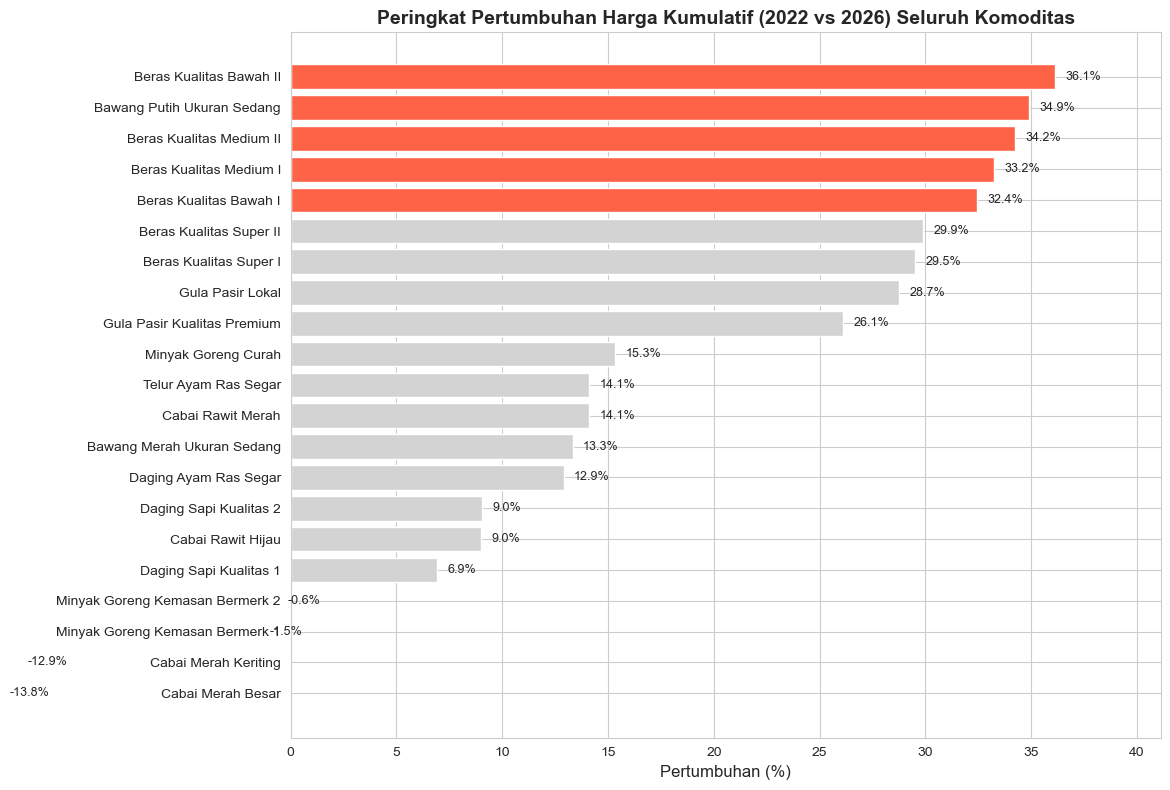

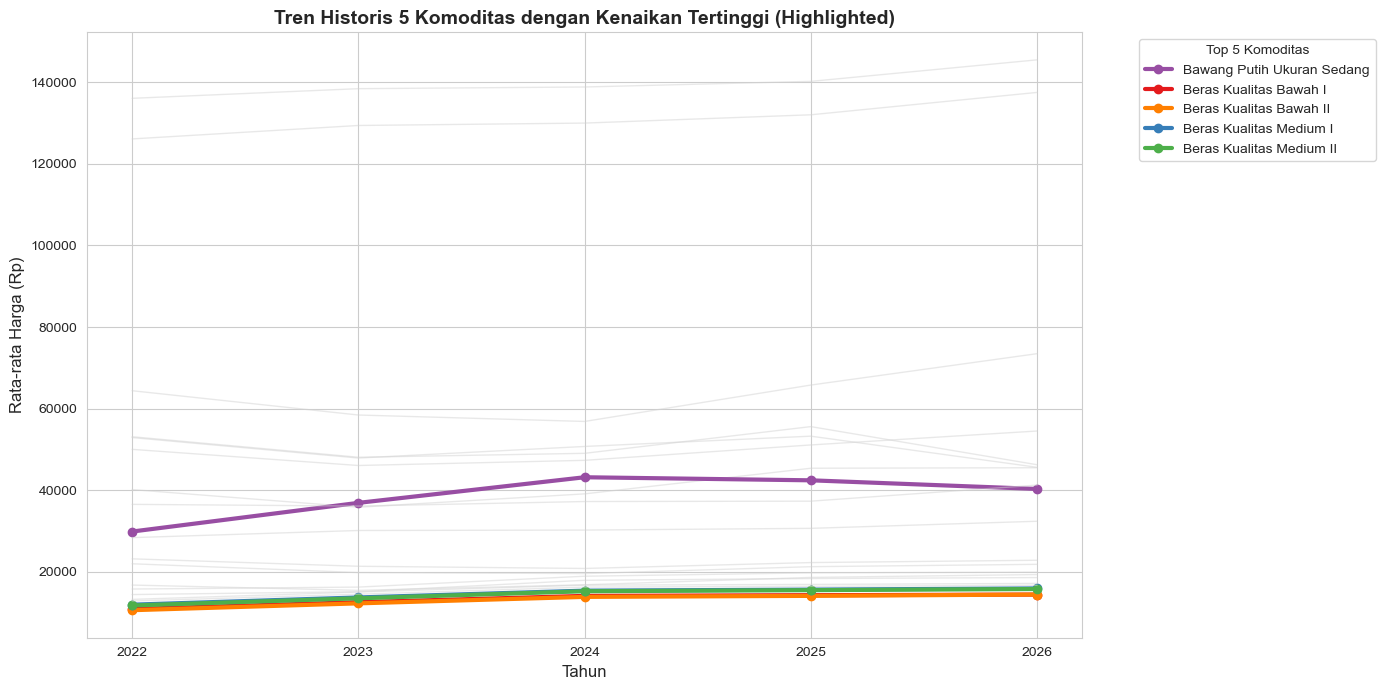

In [11]:
# Filter data tahun 2022 dan 2026
df_2022 = df[df['tahun'] == 2022].groupby('Komoditas')['harga'].mean()
df_2026 = df[df['tahun'] == 2026].groupby('Komoditas')['harga'].mean()

# Hitung persen pertumbuhan kumulatif
growth = ((df_2026 - df_2022) / df_2022 * 100).sort_values(ascending=True)

# Ambil Top 5
top_5_growth = growth.tail(5).index.tolist()

# Visualisasi Bar Chart Peringkat
plt.figure(figsize=(12, 8))
colors = ['tomato' if x in top_5_growth else 'lightgrey' for x in growth.index]
bars = plt.barh(growth.index, growth.values, color=colors)

for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.1f}%", va='center', fontsize=9)

plt.title('Peringkat Pertumbuhan Harga Kumulatif (2022 vs 2026) Seluruh Komoditas', fontsize=14, fontweight='bold')
plt.xlabel('Pertumbuhan (%)', fontsize=12)
plt.xlim(0, max(growth.values) + 5)
plt.tight_layout()
plt.show()

# Visualisasi Line Chart Highlight
plt.figure(figsize=(14, 7))
yoy_all = df.groupby(['tahun', 'Komoditas'])['harga'].mean().unstack('Komoditas')

palette = sns.color_palette("Set1", len(top_5_growth))

for i, col in enumerate(yoy_all.columns):
    if col in top_5_growth:
        plt.plot(yoy_all.index, yoy_all[col], marker='o', linewidth=3, label=col, color=palette[top_5_growth.index(col)])
    else:
        plt.plot(yoy_all.index, yoy_all[col], linewidth=1, color='lightgrey', alpha=0.5)

plt.title('Tren Historis 5 Komoditas dengan Kenaikan Tertinggi (Highlighted)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rata-rata Harga (Rp)', fontsize=12)
plt.xticks([2022, 2023, 2024, 2025, 2026])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Top 5 Komoditas")
plt.tight_layout()
plt.show()


**Insight (Deeper Q1):** Mayoritas komoditas mengalami inflasi positif sejak 2022. Lima komoditas dengan pertumbuhan tertinggi didominasi oleh Beras (berbagai varian) yang melesat signfikan, serta Gula Pasir. Ini membuktikan bahwa inflasi pangan utama bertumpu pada beras, yang mana pola historisnya terlihat melonjak drastis pada transisi 2023 ke 2024.


## 2. Dinamika Volatilitas Waktu Bergulir (Rolling 30-Day Volatility)
**Bagaimana tren volatilitas bergulir per 30 hari dari 2022-2026, dan kapan lonjakan volatilitas terjadi serentak?**


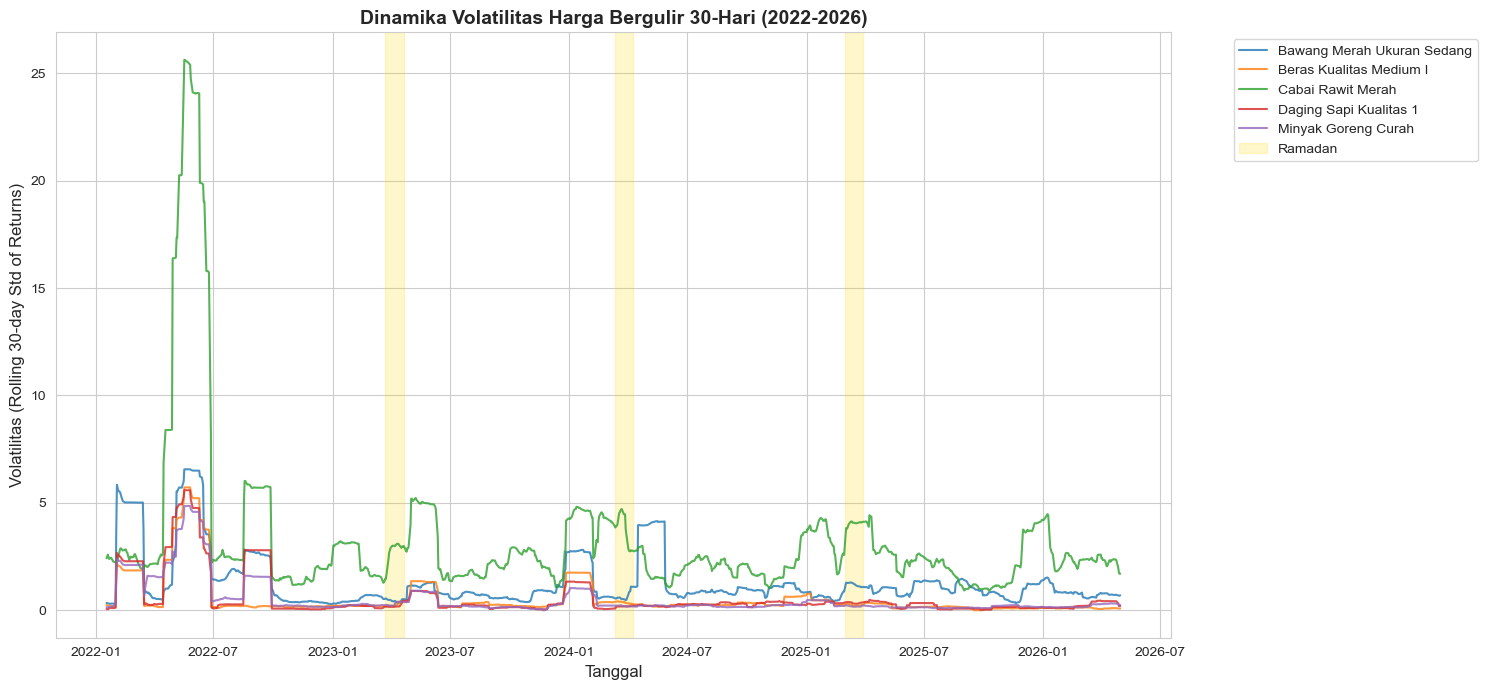

In [ ]:
# Mengambil beberapa sampel komoditas representatif dari tiap kelompok untuk keterbacaan grafik
sample_komoditas = ['Cabai Rawit Merah', 'Bawang Merah Ukuran Sedang', 'Daging Sapi Kualitas 1', 'Beras Kualitas Medium I', 'Minyak Goreng Curah']
df_roll = df[df['Komoditas'].isin(sample_komoditas)].copy()

# Sort & calculate daily return
df_roll.sort_values(by=['Komoditas', 'tanggal'], inplace=True)
df_roll['daily_return'] = df_roll.groupby('Komoditas')['harga'].pct_change() * 100

# Calculate 30-day rolling standard deviation
df_roll['rolling_volatility'] = df_roll.groupby('Komoditas')['daily_return'].transform(lambda x: x.rolling(window=30, min_periods=10).std())

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_roll, x='tanggal', y='rolling_volatility', hue='Komoditas', linewidth=1.5, alpha=0.8)

# Highlight Area Ramadan (Tahun 2023 & 2024)
plt.axvspan(pd.Timestamp('2023-03-23'), pd.Timestamp('2023-04-21'), color='gold', alpha=0.2, label='Ramadan')
plt.axvspan(pd.Timestamp('2024-03-12'), pd.Timestamp('2024-04-09'), color='gold', alpha=0.2)
plt.axvspan(pd.Timestamp('2025-03-01'), pd.Timestamp('2025-03-29'), color='gold', alpha=0.2)

plt.title('Dinamika Volatilitas Harga Bergulir 30-Hari (2022-2026)', fontsize=14, fontweight='bold')
plt.ylabel('Volatilitas (Rolling 30-day Std of Returns)', fontsize=12)
plt.xlabel('Tanggal', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Insight (Deeper Q2):** Volatilitas komoditas bersifat **dinamis**, bukan statis. Terlihat jelas bahwa Cabai Rawit Merah mengalami ledakan volatilitas secara periodik, yang mana puncak-puncak (*spikes*) volatilitas ini seringkali beririsan atau tepat berada di area latar kuning (bulan Ramadan). Daging Sapi dan Beras garisnya nyaris rata di dasar grafik, mengindikasikan mereka tidak memiliki volatilitas jangka pendek meski harganya terus naik jangka panjang.


## 3. Pemeringkatan Dampak Momentum Ramadan (Top 5 Komoditas)
**Apa saja 5 komoditas dengan persentase lonjakan harga tertinggi selama Ramadan dibandingkan bulan reguler?**


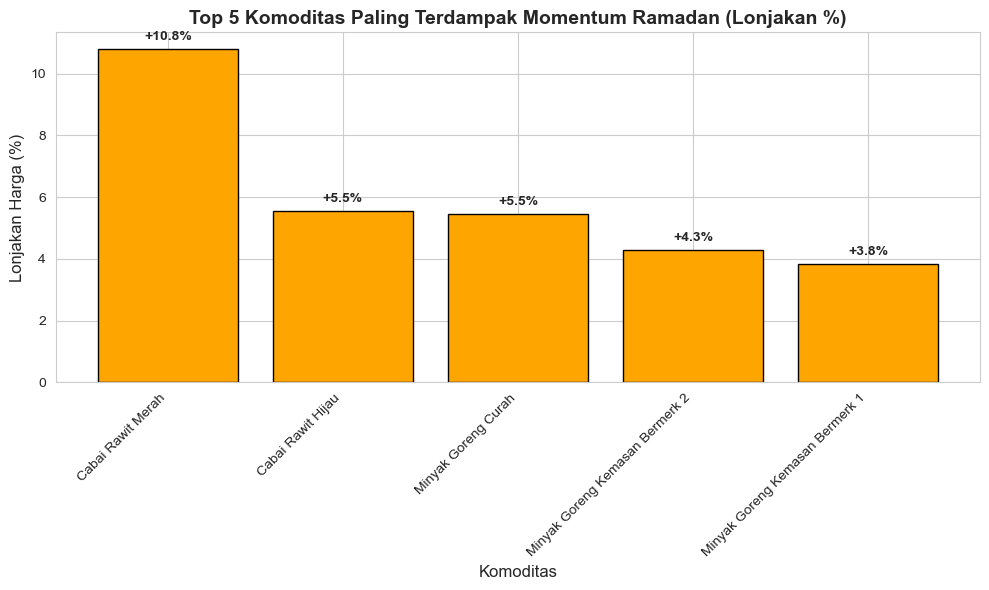

In [16]:
# Hitung rata-rata semua komoditas
ramadan_all = df.groupby(['Komoditas', 'is_ramadan'])['harga'].mean().unstack('is_ramadan')
ramadan_all.columns = ['Bulan_Reguler', 'Bulan_Ramadan']

# Hitung Persentase Delta
ramadan_all['Delta_Persen'] = ((ramadan_all['Bulan_Ramadan'] - ramadan_all['Bulan_Reguler']) / ramadan_all['Bulan_Reguler']) * 100

# Ambil 5 Teratas
top_5_ramadan = ramadan_all.sort_values('Delta_Persen', ascending=False).head(5)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_5_ramadan.index, top_5_ramadan['Delta_Persen'], color='orange', edgecolor='black')

plt.title('Top 5 Komoditas Paling Terdampak Momentum Ramadan (Lonjakan %)', fontsize=14, fontweight='bold')
plt.ylabel('Lonjakan Harga (%)', fontsize=12)
plt.xlabel('Komoditas', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"+{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


**Insight (Deeper Q3):** Cabai Rawit Merah merajai dampak Ramadan dengan lonjakan harga rata-rata menyentuh kisaran 10.8% lebih mahal dibandingkan bulan biasa. Diikuti oleh Minyak Goreng Curah dan varian Cabai Rawit Hijau. Ini menegaskan bahwa spekulasi dan lonjakan *demand* Lebaran sangat terpusat pada bahan pembuat bumbu dan minyak.


## 4. Matriks Sensitivitas Cuaca Terhadap Keseluruhan Pangan
**Bagaimana matriks korelasi faktor cuaca (hujan & suhu) terhadap fluktuasi harga 21 komoditas, dan kelompok mana yang paling sensitif?**


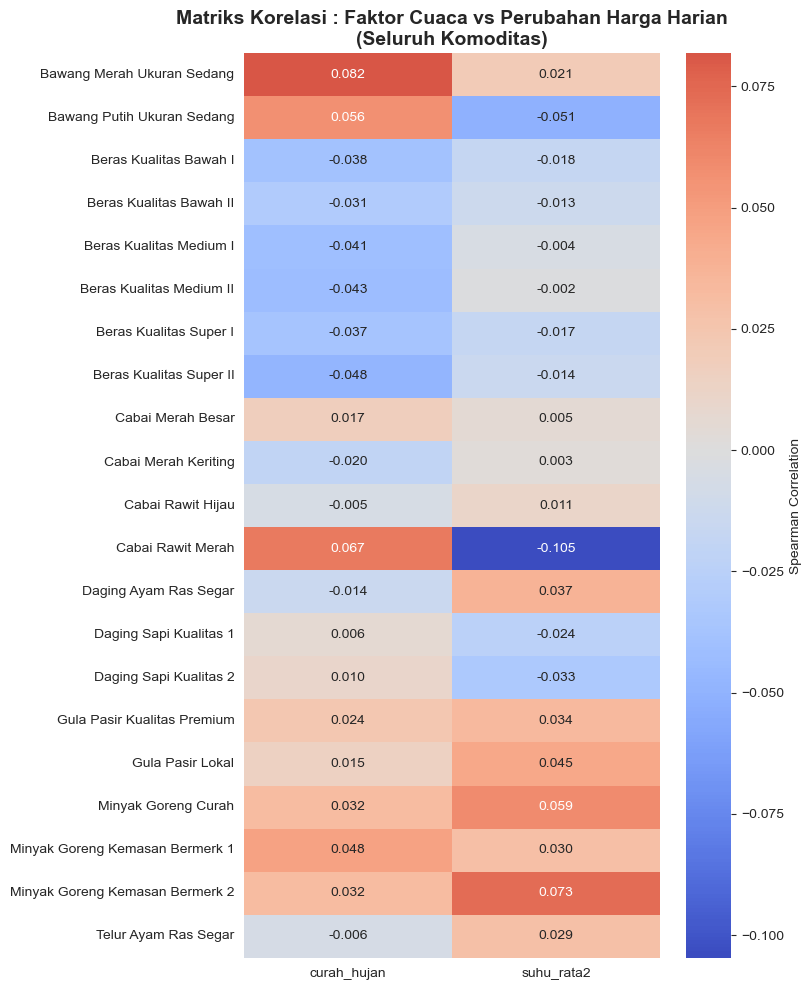

In [17]:
# Sort & hitung daily returns semua komoditas
df.sort_values(by=['Komoditas', 'tanggal'], inplace=True)
df['daily_return'] = df.groupby('Komoditas')['harga'].pct_change() * 100

# Dropna
df_corr = df.dropna(subset=['daily_return', 'curah_hujan', 'suhu_rata2'])

# Hitung korelasi spearman
corr_matrix = df_corr.groupby('Komoditas')[['daily_return', 'curah_hujan', 'suhu_rata2']].corr(method='spearman')

# Extract nilai korelasi terhadap curah_hujan dan suhu_rata2
weather_corr = corr_matrix.loc[(slice(None), 'daily_return'), ['curah_hujan', 'suhu_rata2']].reset_index(level=1, drop=True)

plt.figure(figsize=(8, 10))
sns.heatmap(weather_corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', cbar_kws={'label': 'Spearman Correlation'})
plt.title('Matriks Korelasi : Faktor Cuaca vs Perubahan Harga Harian\n(Seluruh Komoditas)', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Insight (Deeper Q4):** *Heatmap* membuktikan bahwa korelasi harian langsung (lag-0) antara cuaca dan harga **semua komoditas** secara statistik tergolong lemah (mendekati 0). Tidak ada perbedaan radikal antara kelompok hortikultura dengan non-hortikultura (seperti Daging) di hari yang persis sama saat hujan turun. Kesimpulannya, cuaca tidak menciptakan *shock* instan pada hari-H di pasar ritel, melainkan berdampak sistemik yang butuh perhitungan pergeseran waktu (*time-lag*).


---
# Conclusion (Kesimpulan Akhir)

Berdasarkan integrasi dari analisis dasar dan analisis mendalam (*deeper analysis*), berikut adalah  kesimpulan yang didaparkan:

1. **Inflasi Bersifat Strutural pada Makanan Pokok**: 
   Harga pangan tidak sekadar berfluktuasi, tetapi mengalami kenaikan struktural. Kelompok Beras menjadi penyumbang pertumbuhan akumulatif paling parah (Top 5) sepanjang 2022-2026. *Dashboard* kelak wajib menampilkan garis *baseline* historis untuk menyadarkan pengguna bahwa "harga normal" hari ini jauh lebih tinggi dari 4 tahun lalu.
   
2. **Karakter Volatilitas Spesifik per Komoditas**: 
   Pasar terbagi secara ekstrem. Daging Sapi adalah komoditas dengan pertumbuhan lambat namun super stabil (CV <3%, nyaris *flat* pada *rolling volatility*). Di sisi lain, komoditas hortikultura terutama **Cabai Rawit Merah** sangat liar (CV 24%). Fluktuasi ini bukan sekadar *noise* acak, melainkan ritme pasar yang repetitif.

3. **Sentimen Ramadan Memicu Krisis Sesekali (Shock)**: 
   Analisis dampak momentum dengan jelas mengkuantifikasi bahwa bulan Ramadan merupakan katalis utama kenaikan harga, secara spesifik pada **Cabai Rawit Merah (+11%), Cabai Rawit Hijau (+5.6%), dan Minyak Goreng Curah (+5.5%)**. Pemodelan prediksi masa depan wajib menggunakan `is_ramadan` sebagai fitur eksogen.
   
4. **Anomali Korelasi Cuaca (Butuh Transformasi Fitur)**: 
   Meskipun cuaca ekstrem logikanya menghancurkan panen, analisis *Matriks Sensitivitas* menemukan bahwa korelasi harian (hujan lebat hari ini vs kenaikan harga hari ini) bernilai lemah untuk semua 21 komoditas. Ini adalah *insight* penting untuk *Machine Learning Engineer*: Variabel cuaca harus ditransformasi menggunakan teknik **Time-Lag** (misal: rata-rata hujan 14 hari ke belakang) agar kekuatan prediktifnya muncul, karena disrupsi logistik butuh waktu berminggu-minggu sebelum menghantam pasar ritel konsumen.
